In [1]:
# Convert phenotypes: FFMQ
# Five Facet Mindfulness Questionnaire (FFMQ; Baer et al., 2008). 
# The FFMQ is a 39-item questionnaire that measures five component skills of mindfulness.  

# Import necessary libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Initialization
file_name = '~/Documents/Github/consciousness/code/Final_launch.xlsx'
fl = pd.read_excel(file_name)
# Drop only the first row from the dataframe
fl = fl.drop(0, axis=0).reset_index(drop=True)  # Drop the first row (index 0)

# Define the mapping of text responses to numeric values
response_mapping = {
    "Never or very rarely true": 1,
    "Rarely true": 2,
    "Sometimes true": 3,
    "Often true": 4,
    "Very often or always true": 5
}

# List of columns from the FFMQ survey (FF_1 to FF_39)
ffmq_columns = [f'FF_{i}' for i in range(1, 40)]

# Apply the mapping to convert text responses to numeric values for the FFMQ columns
fl[ffmq_columns] = fl[ffmq_columns].applymap(lambda x: response_mapping.get(x, np.nan))  # Handle missing values gracefully

# List of items to be reverse scored
reverse_scored_items = [12, 16, 22, 5, 8, 13, 18, 23, 28, 34, 38, 3, 10, 14, 17, 25, 30, 35, 39]

# Reverse scoring for the specified items
# Reverse scoring is done by subtracting the score from 6 (since we are working with scores 1 to 5)
for item in reverse_scored_items:
    fl[f'FF_{item}'] = 6 - fl[f'FF_{item}']

# Create a new column 'FF_total' which is the sum of all FFMQ items (FF_1 to FF_39)
fl['FF_total'] = fl[ffmq_columns].sum(axis=1)

# Create a new column 'FF_avg' which is the average of all FFMQ items (total score divided by the number of items, 39)
fl['FF_avg'] = fl['FF_total'] / 39

# Display the first few rows to check the results
print(fl[['FF_total', 'FF_avg']].head())

# Create a more aesthetically pleasing histogram with KDE
#plt.figure(figsize=(8, 6))
#sns.histplot(fl['FF_avg'], bins=20, kde=True, color='lightblue')

# Customize the appearance of the plot
#plt.title('Histogram of FF_avg (Average FFMQ Score)', fontsize=14)
#plt.xlabel('FF_avg', fontsize=12)
#plt.ylabel('Frequency', fontsize=12)

# Customize the x-axis to show all possible values (1 to 5, since responses are between 1 and 5)
#plt.xticks([1, 2, 3, 4, 5])

# Remove grid lines
#plt.grid(False)

# Show the plot
#plt.show()


   FF_total    FF_avg
0       118  3.025641
1       113  2.897436
2       143  3.666667
3       127  3.256410
4       115  2.948718


In [3]:
# Convert phenotypes: EBDM
# Emotion-Based Decision-Making Scale (EBDMS; Evans & Barchard, 2005). 
# The EBDMS is a 10-item scale that was designed to measure the tendency to make decisions based upon emotions. 

# Define the mapping of text responses to numeric values for the EBDM survey
ebdm_mapping = {
    "Very inaccurate": 1,
    "Moderately inaccurate": 2,
    "Neither accurate nor inaccurate": 3,
    "Moderately accurate": 4,
    "Very accurate": 5
}

# List of columns for the EBDM survey (excluding EBDM_7)
ebdm_columns = [f'EBDM_{i}' for i in range(1, 12) if i != 7]

# Apply the mapping to convert text responses to numeric values for the EBDM columns
fl[ebdm_columns] = fl[ebdm_columns].applymap(ebdm_mapping.get)

# List of items to be reverse scored (EBDM_6 through EBDM_11)
reverse_scored_ebdm = [6, 8, 9, 10, 11]

# Reverse scoring for the specified EBDM items
# Reverse scoring is done by subtracting the score from 6 (since the scale is 1 to 5)
for item in reverse_scored_ebdm:
    fl[f'EBDM_{item}'] = 6 - fl[f'EBDM_{item}']

# Create a new column 'EBDM_total' which is the sum of all EBDM items (EBDM_1 to EBDM_11, excluding EBDM_7)
fl['EBDM_total'] = fl[ebdm_columns].sum(axis=1)

# Create a new column 'EBDM_avg' which is the average of all EBDM items (total score divided by 10, since we have 10 items)
fl['EBDM_avg'] = fl['EBDM_total'] / 10

# Display the first few rows to check the results
print(fl[['EBDM_total', 'EBDM_avg']].head())

# Create a histogram for EBDM_avg with KDE and all possible x-axis values
#plt.figure(figsize=(8, 6))
#sns.histplot(fl['EBDM_avg'], bins=10, kde=True, color='lightblue')

# Customize the x-axis to show all possible values (1 to 5, since responses are between 1 and 5)
#plt.xticks([1, 2, 3, 4, 5])

# Customize the appearance of the plot
#plt.title('Histogram of EBDM_avg (Average EBDM Score)', fontsize=14)
#plt.xlabel('EBDM_avg', fontsize=12)
#plt.ylabel('Frequency', fontsize=12)

# Remove grid lines
#plt.grid(False)

# Show the plot
#plt.show()

   EBDM_total  EBDM_avg
0          30       3.0
1          25       2.5
2          27       2.7
3          22       2.2
4          43       4.3


In [5]:
# Convert phenotypes: Scam Susceptibility
# Scam Susceptibility Scale (AARP, 1999; Financial Industry Regulatory Authority, 2013)
# This five question scale assesses scam susceptibility using questions from findings and official statements from AARP and the Financial Industry Regulatory Authority. 

# Define the mapping of text responses to numeric values for the Scam Susceptibility Scale
scam_mapping = {
    "Strongly agree": 1,
    "Agree": 2,
    "Slightly agree": 3,
    "Neither agree nor disagree": 4,
    "Slightly disagree": 5,
    "Disagree": 6,
    "Strongly disagree": 7
}

# List of columns for the Scam Susceptibility Scale (Scam Susceptibility_1 to Scam Susceptibility_5)
scam_columns = [f'Scam Susceptibility_{i}' for i in range(1, 6)]

# Apply the mapping to convert text responses to numeric values for the Scam Susceptibility columns
fl[scam_columns] = fl[scam_columns].applymap(scam_mapping.get)

# List of items to be reverse scored (Scam Susceptibility_1, Scam Susceptibility_2, Scam Susceptibility_5)
reverse_scored_scam = [1, 2, 5]

# Reverse scoring for the specified Scam Susceptibility items
# Reverse scoring is done by subtracting the score from 8 (since the scale is 1 to 7)
for item in reverse_scored_scam:
    fl[f'Scam Susceptibility_{item}'] = 8 - fl[f'Scam Susceptibility_{item}']

# Create a new column 'Scam_Susceptibility_total' which is the sum of all Scam Susceptibility items
fl['Scam_Susceptibility_total'] = fl[scam_columns].sum(axis=1)

# Create a new column 'Scam_Susceptibility_avg' which is the average of all Scam Susceptibility items (total score divided by 5, since we have 5 items)
fl['Scam_Susceptibility_avg'] = fl['Scam_Susceptibility_total'] / 5

# Display the first few rows to check the results
print(fl[['Scam_Susceptibility_total', 'Scam_Susceptibility_avg']].head())

# Create a histogram for Scam_Susceptibility_avg with KDE and all possible x-axis values
#plt.figure(figsize=(8, 6))
#sns.histplot(combined_df['Scam_Susceptibility_avg'], bins=7, kde=True, color='lightblue')

# Customize the x-axis to show all possible values (1 to 7, since responses are between 1 and 7)
#plt.xticks([1, 2, 3, 4, 5, 6, 7])

# Customize the appearance of the plot
#plt.title('Histogram of Scam_Susceptibility_avg (Average Scam Susceptibility Score)', fontsize=14)
#plt.xlabel('Scam_Susceptibility_avg', fontsize=12)
#plt.ylabel('Frequency', fontsize=12)

# Remove grid lines
#plt.grid(False)

# Show the plot
#plt.show()

   Scam_Susceptibility_total  Scam_Susceptibility_avg
0                         23                      4.6
1                         23                      4.6
2                         11                      2.2
3                         33                      6.6
4                          9                      1.8


In [7]:
# NOTE: OUR CURRENT MEASURE OF FEVS FOR THIS SURVEY ONLY INCLUDES 3 ITEMS

# Convert Phenotypes: FEVS
# Financial Exploitation Vulnerability Scale (FEVS; Lichtenberg et al., 2020) 
# The FEVS is a 17-item scale used to assess personal finance as it relates to financial, psychological, and relationship insecurities. 

# Define the mapping for FEVS responses
fevs_mapping = {"Yes": 2, "Somewhat": 1, "No": 0}

# Apply the mapping to FEVS columns
fl['FEVS_1'] = fl['FEVS_1'].map(fevs_mapping)
fl['FEVS_2'] = fl['FEVS_2'].map(fevs_mapping)
fl['FEVS_3'] = fl['FEVS_3'].map(fevs_mapping)

# Check if there are any missing values in the mapped columns (optional)
#print(combined_df[['FEVS_1', 'FEVS_2', 'FEVS_3']].isnull().sum())

# Generate the total and average scores for the FEVS measure
fl['FEVS_total'] = fl[['FEVS_1', 'FEVS_2', 'FEVS_3']].sum(axis=1)
fl['FEVS_avg'] = fl[['FEVS_1', 'FEVS_2', 'FEVS_3']].mean(axis=1)

# Preview the updated DataFrame to check the changes
print(fl[['FEVS_total', 'FEVS_avg']].head())

   FEVS_total  FEVS_avg
0           5  1.666667
1           0  0.000000
2           3  1.000000
3           4  1.333333
4           1  0.333333


In [9]:
# Convert Phenotypes: CB
# Confirmation Bias Scale (Rassin, 2008)
# This fourteen-question scale measures an indivisuals susceptibility to confirmation bias.

# Define the mapping of text responses to numeric values for the Confirmation Bias Scale
confirmation_bias_mapping = {
    "Strongly Disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly Agree": 5
}

# List of columns for the Confirmation Bias Scale (excluding Confirmation bias_12)
confirmation_bias_columns = [f'Confirmation bias_{i}' for i in range(1, 16) if i != 12]

# Apply the mapping to convert text responses to numeric values for the Confirmation Bias columns
fl[confirmation_bias_columns] = fl[confirmation_bias_columns].applymap(confirmation_bias_mapping.get)

# List of items to be reverse scored (Confirmation bias_11, Confirmation bias_14)
reverse_scored_confirmation_bias = [11, 14]

# Reverse scoring for the specified Confirmation Bias items
# Reverse scoring is done by subtracting the score from 6 (since the scale is 1 to 5)
for item in reverse_scored_confirmation_bias:
    fl[f'Confirmation bias_{item}'] = 6 - fl[f'Confirmation bias_{item}']

# Create a new column 'Confirmation_bias_total' which is the sum of all Confirmation Bias items
fl['Confirmation_bias_total'] = fl[confirmation_bias_columns].sum(axis=1)

# Create a new column 'Confirmation_bias_avg' which is the average of all Confirmation Bias items (total score divided by 14, since we have 14 items)
fl['Confirmation_bias_avg'] = fl['Confirmation_bias_total'] / 14

# Display the first few rows to check the results
print(fl[['Confirmation_bias_total', 'Confirmation_bias_avg']].head())

# Create a histogram for Confirmation_bias_avg with KDE and all possible x-axis values
#plt.figure(figsize=(8, 6))
#sns.histplot(fl['Confirmation_bias_avg'], bins=5, kde=True, color='lightblue')

# Customize the x-axis to show all possible values (1 to 5, since responses are between 1 and 5)
#plt.xticks([1, 2, 3, 4, 5])

# Customize the appearance of the plot
#plt.title('Histogram of Confirmation_bias_avg (Average Confirmation Bias Score)', fontsize=14)
#plt.xlabel('Confirmation_bias_avg', fontsize=12)
#plt.ylabel('Frequency', fontsize=12)

# Remove grid lines
#plt.grid(False)

# Show the plot
#plt.show()

   Confirmation_bias_total  Confirmation_bias_avg
0                       57               4.071429
1                       26               1.857143
2                       43               3.071429
3                       41               2.928571
4                       40               2.857143


['Education', 'Age', 'Gender', 'Race', 'Ethnicity', 'current_zipcode', 'when_move', 'Q64_First Click', 'Q64_Last Click', 'Q64_Page Submit', 'Q64_Click Count', 'Q65_First Click', 'Q65_Last Click', 'Q65_Page Submit', 'Q65_Click Count', 'FF_1', 'FF_2', 'FF_3', 'FF_4', 'FF_5', 'FF_6', 'FF_7', 'FF_8', 'FF_9', 'FF_10', 'FF_11', 'FF_12', 'FF_13', 'FF_14', 'FF_15', 'FF_16', 'FF_17', 'FF_18', 'FF_19', 'FF_20', 'FF_21', 'FF_22', 'FF_23', 'FF_24', 'FF_25', 'FF_26', 'FF_27', 'FF_28', 'FF_29', 'FF_30', 'FF_31', 'FF_32', 'FF_33', 'FF_34', 'FF_35', 'FF_36', 'FF_37', 'FF_38', 'FF_39', 'Q67_First Click', 'Q67_Last Click', 'Q67_Page Submit', 'Q67_Click Count', 'EBDM_1', 'EBDM_2', 'EBDM_3', 'EBDM_4', 'EBDM_5', 'EBDM_6', 'EBDM_7', 'EBDM_8', 'EBDM_9', 'EBDM_10', 'EBDM_11', 'Q68_First Click', 'Q68_Last Click', 'Q68_Page Submit', 'Q68_Click Count', 'Confirmation bias_1', 'Confirmation bias_2', 'Confirmation bias_3', 'Confirmation bias_4', 'Confirmation bias_5', 'Confirmation bias_6', 'Confirmation bias_7', '

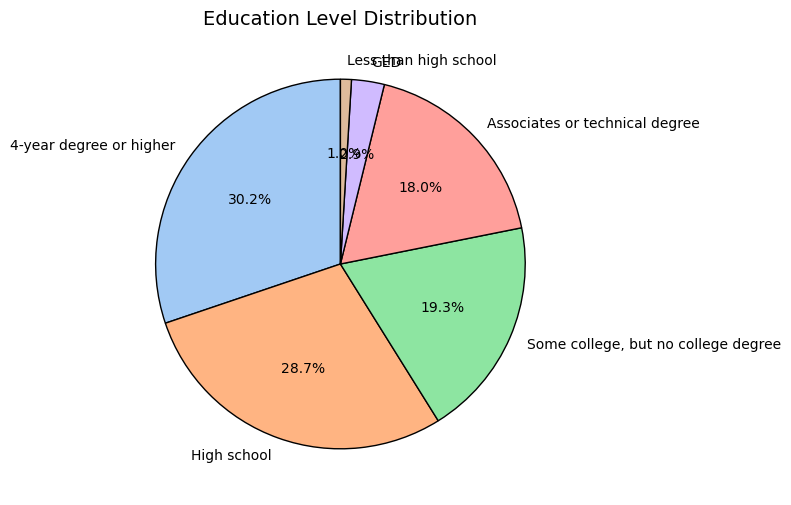

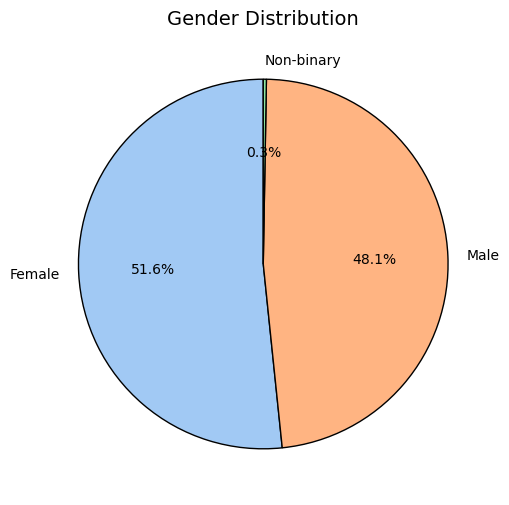

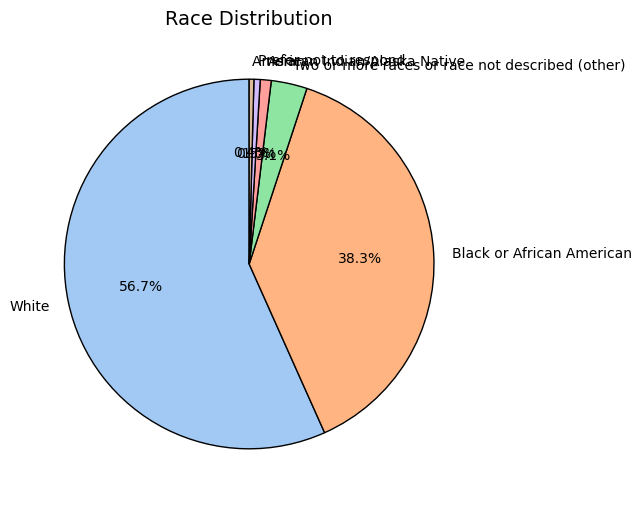

<Figure size 1000x800 with 0 Axes>

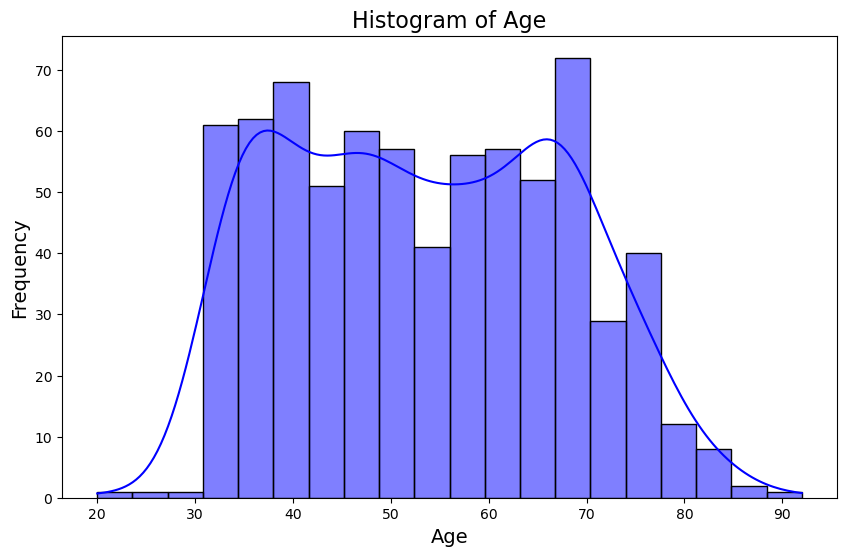

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Strip spaces from column names
fl.columns = fl.columns.str.strip()

# Print all columns to inspect for discrepancies
print(fl.columns.tolist())

# Define a function to create a pie chart with custom aesthetics
def create_pie_chart(column, title):
    plt.figure(figsize=(6, 6))
    
    # Calculate the percentage of each category in the column
    fl[column].value_counts().plot.pie(
        autopct='%1.1f%%', 
        startangle=90, 
        colors=sns.color_palette('pastel'),  # Using pastel colors for a soft look
        wedgeprops={'edgecolor': 'black'}
    )
    
    # Customize the appearance
    plt.title(f'{title}', fontsize=14)
    plt.ylabel('')  # Hide the y-label for a cleaner look
    
    # Show the plot
    plt.show()

# Create pie charts for 'Education', 'Gender', and 'Race'
create_pie_chart('Education', 'Education Level Distribution')
create_pie_chart('Gender', 'Gender Distribution')
create_pie_chart('Race', 'Race Distribution')

# Correlation heatmap for the relevant columns
correlation_data = fl[['Age', 'FF_avg', 'EBDM_avg', 'Scam_Susceptibility_avg', 'Confirmation_bias_avg', 'FEVS_avg']]

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Create the histogram for Age
plt.figure(figsize=(10, 6))  # Optional: Adjust figure size
sns.histplot(data=fl, x='Age', bins=20, kde=True, color='blue')

# Add labels and title
plt.xlabel('Age', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.title('Histogram of Age', fontsize=16)

# Show the plot
plt.show()


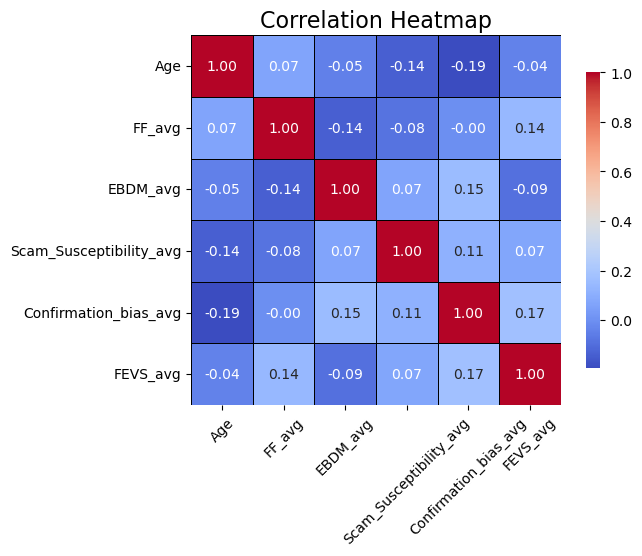

In [17]:
# Create a heatmap using seaborn
sns.heatmap(
    correlation_matrix,
    annot=True,          # Annotate cells with the correlation coefficients
    cmap='coolwarm',     # Color palette
    square=True,         # Make cells square-shaped
    cbar_kws={"shrink": .8},  # Adjust the color bar size
    fmt=".2f",          # Format the annotations to two decimal places
    linewidths=0.5,     # Lines between cells
    linecolor='black'    # Color of the lines between cells
)

# Customize the appearance
plt.title('Correlation Heatmap', fontsize=16)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.yticks(rotation=0)   # Keep y-axis labels horizontal

# Show the plot
plt.show()

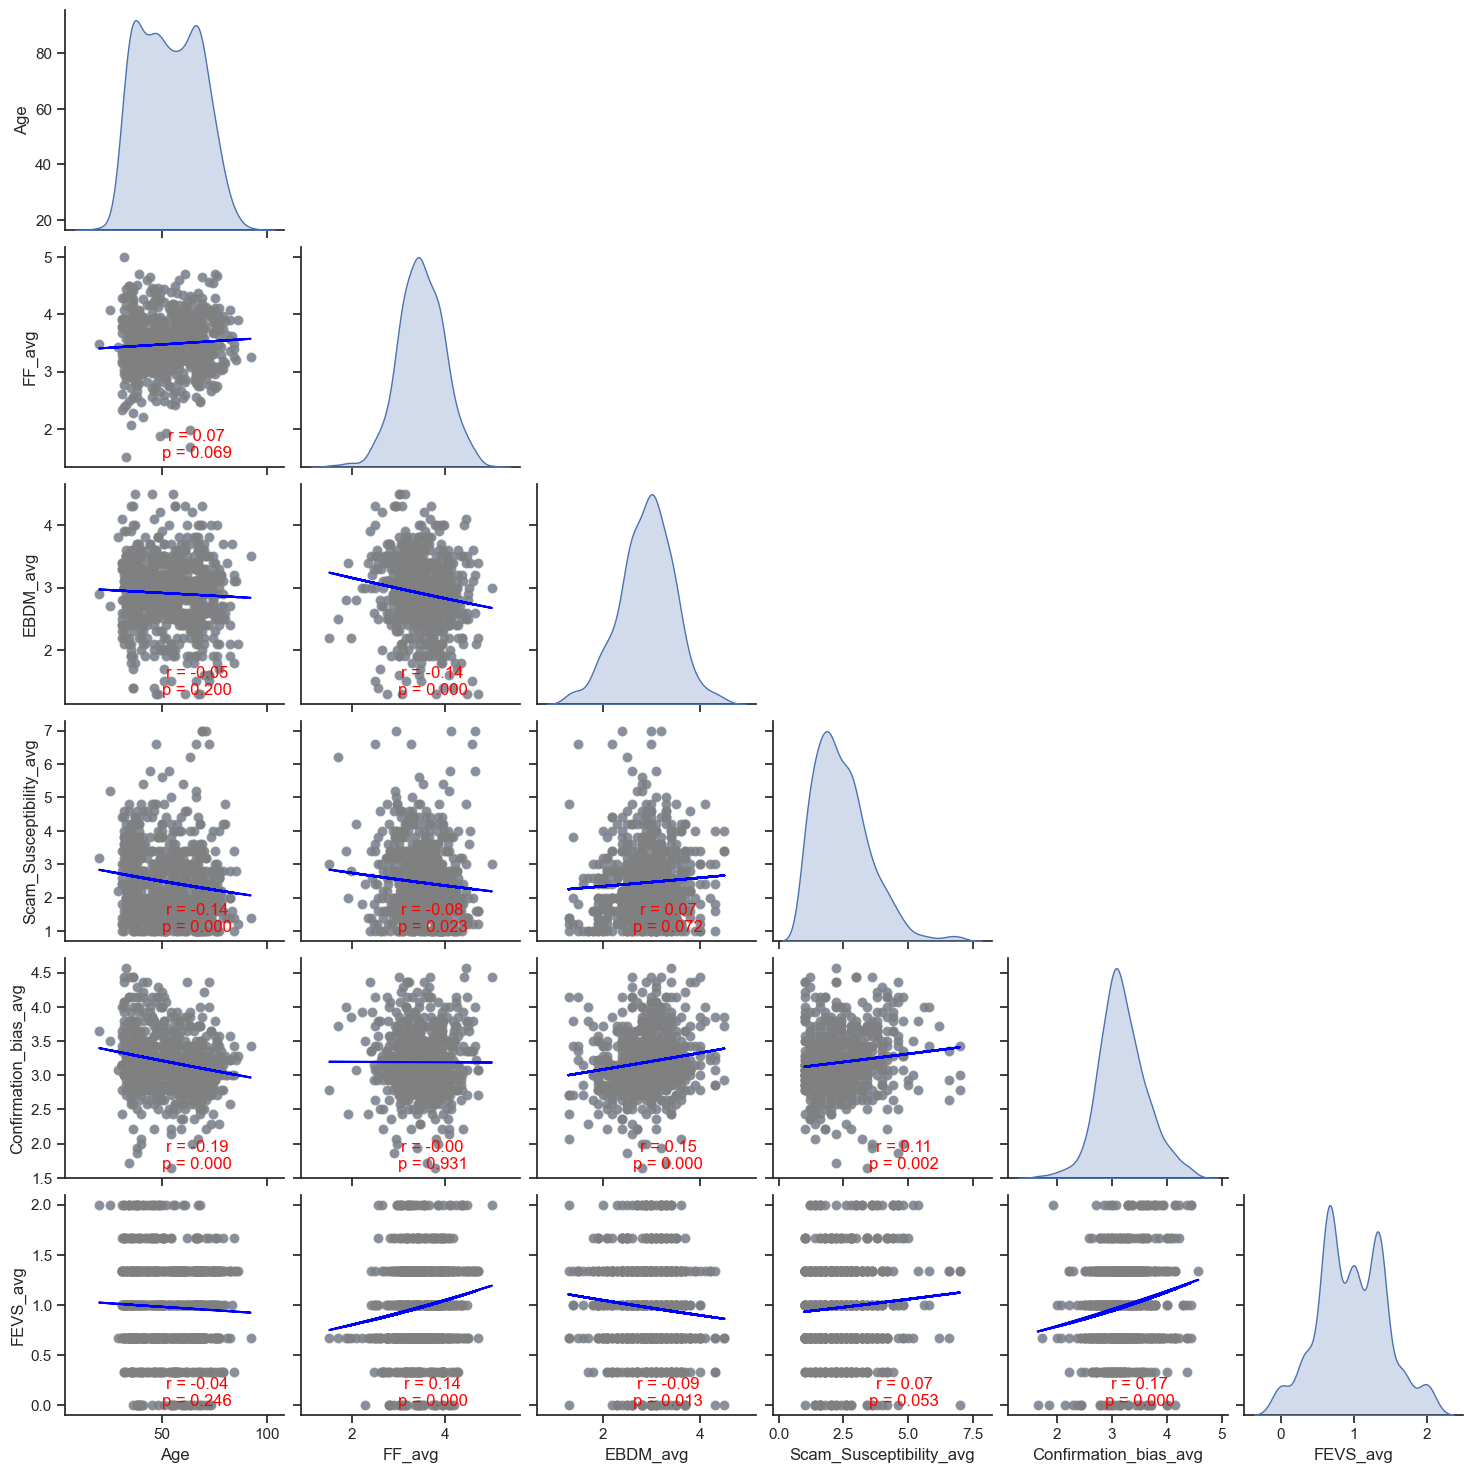

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import pearsonr
import statsmodels.api as sm 
import numpy as np

# List of variables to analyze
variables = ['Age', 'FF_avg', 'EBDM_avg', 'Scam_Susceptibility_avg', 'Confirmation_bias_avg', 'FEVS_avg']

# Drop rows with missing values in these columns
fl = fl[variables].dropna()

# Ensure all variables are numeric
fl = fl.apply(pd.to_numeric, errors='coerce')

# Create a pairplot with scatterplots and Poisson regression trendlines
sns.set(style="ticks")

# Pairplot for all variables
g = sns.pairplot(fl, diag_kind='kde', kind='scatter', 
                 plot_kws={'alpha': 0.6, 's': 40})

# Loop through axes to add Pearson's r, p-values, and Poisson regression trendlines
for i, j in zip(*np.tril_indices_from(g.axes, -1)):
    x_var = variables[j]
    y_var = variables[i]
    
    x = fl[x_var]
    y = fl[y_var]
    
    # Add scatterplot
    ax = g.axes[i, j]
    ax.scatter(x, y, alpha=0.6, s=40, color='gray')

    # Fit Poisson regression
    X = sm.add_constant(x)  # Add intercept
    poisson_model = sm.GLM(y, X, family=sm.families.Poisson()).fit()
    y_pred = poisson_model.predict(X)
    ax.plot(x, y_pred, color='blue', label='Poisson fit')

    # Pearson correlation and p-value
    r, p = pearsonr(x, y)
    ax.annotate(f'r = {r:.2f}\np = {p:.3f}', 
                xy=(0.6, 0.1), xycoords='axes fraction', 
                ha='center', va='center', fontsize=12, color='red')

# Hide the upper triangle (leaving it blank)
for i, j in zip(*np.triu_indices_from(g.axes, 1)):
    g.axes[i, j].set_visible(False)

# Show the plot
plt.show()


Model: FEVS ~ FFMQ * Age

                 Generalized Linear Model Regression Results                  
Dep. Variable:               FEVS_avg   No. Observations:                  732
Model:                            GLM   Df Residuals:                      728
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -774.24
Date:                Mon, 27 Jan 2025   Deviance:                       180.74
Time:                        19:33:38   Pearson chi2:                     155.
No. Iterations:                     4   Pseudo R-squ. (CS):           0.004989
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const     

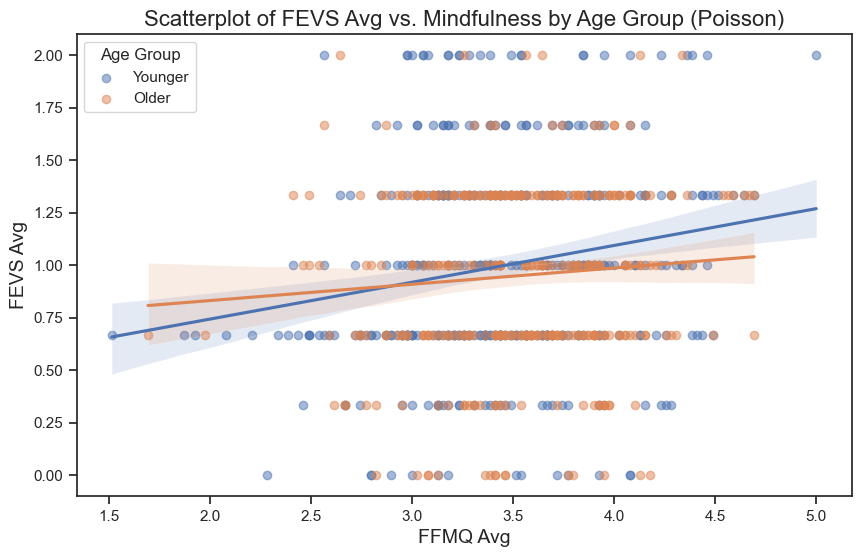

In [21]:
print("Model: FEVS ~ FFMQ * Age\n") #Poisson regression

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import pearsonr
import statsmodels.api as sm 
import numpy as np

# Assuming 'fl' already exists and has the relevant data.
# Ensure 'FF_avg', 'Age', and 'FEVS_avg' are numeric
fl['FF_avg'] = pd.to_numeric(fl['FF_avg'], errors='coerce')
fl['Age'] = pd.to_numeric(fl['Age'], errors='coerce')
fl['FEVS_avg'] = pd.to_numeric(fl['FEVS_avg'], errors='coerce')

# Drop any rows with missing values in the required columns
fl = fl.dropna(subset=['FF_avg', 'Age', 'FEVS_avg'])

# Create the interaction term between Age and FF_avg
fl['Age_FF_Interaction'] = fl['Age'] * fl['FF_avg']

# Prepare the independent variables (FF_avg, Age, and the interaction term)
X = fl[['FF_avg', 'Age', 'Age_FF_Interaction']]

# Add a constant for the intercept
X = sm.add_constant(X)

# Dependent variable
y = fl['FEVS_avg']

# Fit the Poisson regression model
poisson_model = sm.GLM(y, X, family=sm.families.Poisson()).fit()

# Output the regression results
print(poisson_model.summary())

# Create scatterplot with different colors for age groups with trend lines and confidence intervals
fl['Age_Group'] = np.where(fl['Age'] >= 55, 'Older', 'Younger')

plt.figure(figsize=(10, 6))
for age_group in fl['Age_Group'].unique():
    subset = fl[fl['Age_Group'] == age_group]
    sns.regplot(x='FF_avg', y='FEVS_avg', data=subset, 
                label=age_group, 
                scatter_kws={'alpha': 0.5}, 
                line_kws={},  # No label for trend line
                ci=95,  # 95% confidence interval
                logx=False)  # Keep regression consistent with Poisson

plt.title('Scatterplot of FEVS Avg vs. Mindfulness by Age Group (Poisson)', fontsize=16)
plt.xlabel('FFMQ Avg', fontsize=14)
plt.ylabel('FEVS Avg', fontsize=14)
plt.legend(title='Age Group')
plt.grid(False)
plt.show()

Model: Scam Susceptibility ~ FFMQ * Age

                    Generalized Linear Model Regression Results                    
Dep. Variable:     Scam_Susceptibility_avg   No. Observations:                  732
Model:                                 GLM   Df Residuals:                      728
Model Family:                      Poisson   Df Model:                            3
Link Function:                         Log   Scale:                          1.0000
Method:                               IRLS   Log-Likelihood:                -1152.2
Date:                     Mon, 27 Jan 2025   Deviance:                       310.30
Time:                             19:33:39   Pearson chi2:                     333.
No. Iterations:                          4   Pseudo R-squ. (CS):            0.01203
Covariance Type:                 nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------

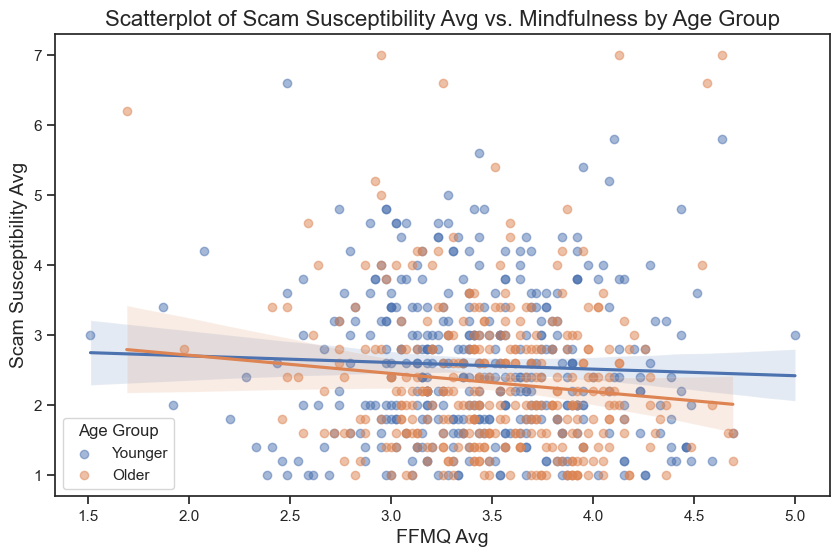

In [23]:
print("Model: Scam Susceptibility ~ FFMQ * Age\n")

import statsmodels.api as sm
import pandas as pd

# Assuming 'fl' already exists and has the relevant data.
# Ensure 'FF_avg' and 'Age' are numeric
fl['FF_avg'] = pd.to_numeric(fl['FF_avg'], errors='coerce')
fl['Age'] = pd.to_numeric(fl['Age'], errors='coerce')
fl['Scam_Susceptibility_avg'] = pd.to_numeric(fl['Scam_Susceptibility_avg'], errors='coerce')

# Drop any rows with missing values in the required columns
fl = fl.dropna(subset=['FF_avg', 'Age', 'Scam_Susceptibility_avg'])

# Create the interaction term between Age and FF_avg
fl['Age_FF_Interaction'] = fl['Age'] * fl['FF_avg']

# Prepare the independent variables (FF_avg, Age, and the interaction term)
X = fl[['FF_avg', 'Age', 'Age_FF_Interaction']]

# Add a constant for the intercept
X = sm.add_constant(X)

# Dependent variable
y = fl['Scam_Susceptibility_avg']

# Fit the Poisson regression model
poisson_model = sm.GLM(y, X, family=sm.families.Poisson()).fit()

# Output the regression results
print(poisson_model.summary())

# Create scatterplot with different colors for age groups with trend lines and confidence intervals
fl['Age_Group'] = np.where(fl['Age'] >= 55, 'Older', 'Younger')
plt.figure(figsize=(10, 6))
for age_group in fl['Age_Group'].unique():
    subset = fl[fl['Age_Group'] == age_group]
    sns.regplot(x='FF_avg', y='Scam_Susceptibility_avg', data=subset, 
                label=age_group, 
                scatter_kws={'alpha': 0.5}, 
                line_kws={},  # No label for trend line
                ci=95)  # 95% confidence interval

plt.title('Scatterplot of Scam Susceptibility Avg vs. Mindfulness by Age Group', fontsize=16)
plt.xlabel('FFMQ Avg', fontsize=14)
plt.ylabel('Scam Susceptibility Avg', fontsize=14)
plt.legend(title='Age Group')
plt.grid(False)
plt.show()

Model: FEVS ~ FFMQ * EBDM

                 Generalized Linear Model Regression Results                  
Dep. Variable:               FEVS_avg   No. Observations:                  732
Model:                            GLM   Df Residuals:                      728
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -774.13
Date:                Mon, 27 Jan 2025   Deviance:                       180.51
Time:                        19:33:39   Pearson chi2:                     155.
No. Iterations:                     4   Pseudo R-squ. (CS):           0.005306
Covariance Type:            nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const  

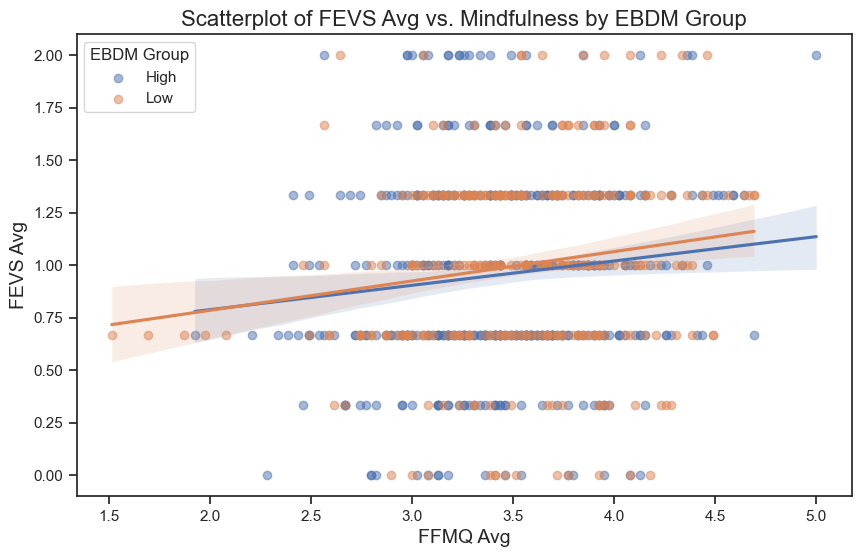

In [25]:
print("Model: FEVS ~ FFMQ * EBDM\n")

import statsmodels.api as sm
import pandas as pd

# Assuming 'combined_df' already exists and has the relevant data.
# Ensure 'FF_avg' and 'Age' are numeric
fl['FF_avg'] = pd.to_numeric(fl['FF_avg'], errors='coerce')
fl['EBDM_avg'] = pd.to_numeric(fl['EBDM_avg'], errors='coerce')
fl['FEVS_avg'] = pd.to_numeric(fl['FEVS_avg'], errors='coerce')

# Drop any rows with missing values in the required columns
fl = fl.dropna(subset=['FF_avg', 'EBDM_avg', 'FEVS_avg'])

# Create the interaction term between Age and FF_avg
fl['EBDM_FF_Interaction'] = fl['EBDM_avg'] * fl['FF_avg']

# Prepare the independent variables (FF_avg, Age, and the interaction term)
X = fl[['FF_avg', 'EBDM_avg', 'EBDM_FF_Interaction']]

# Add a constant for the intercept
X = sm.add_constant(X)

# Dependent variable
y = fl['FEVS_avg']

# Fit the Poisson regression model
poisson_model = sm.GLM(y, X, family=sm.families.Poisson()).fit()

# Output the regression results
print(poisson_model.summary())

# Create scatterplot with different colors for age groups with trend lines and confidence intervals
fl['EBDM_Group'] = np.where(fl['EBDM_avg'] >= fl['EBDM_avg'].median(), 'High', 'Low')
plt.figure(figsize=(10, 6))
for ebdm_group in fl['EBDM_Group'].unique():
    subset = fl[fl['EBDM_Group'] == ebdm_group]
    sns.regplot(x='FF_avg', y='FEVS_avg', data=subset, 
                label=ebdm_group, 
                scatter_kws={'alpha': 0.5}, 
                line_kws={},  # No label for trend line
                ci=95)  # 95% confidence interval

plt.title('Scatterplot of FEVS Avg vs. Mindfulness by EBDM Group', fontsize=16)
plt.xlabel('FFMQ Avg', fontsize=14)
plt.ylabel('FEVS Avg', fontsize=14)
plt.legend(title='EBDM Group')
plt.grid(False)
plt.show()

Model: Scam Susceptibility ~ FFMQ * EBDM

                    Generalized Linear Model Regression Results                    
Dep. Variable:     Scam_Susceptibility_avg   No. Observations:                  732
Model:                                 GLM   Df Residuals:                      728
Model Family:                      Poisson   Df Model:                            3
Link Function:                         Log   Scale:                          1.0000
Method:                               IRLS   Log-Likelihood:                -1154.7
Date:                     Mon, 27 Jan 2025   Deviance:                       315.18
Time:                             19:33:40   Pearson chi2:                     337.
No. Iterations:                          4   Pseudo R-squ. (CS):           0.005420
Covariance Type:                 nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
------------------------------

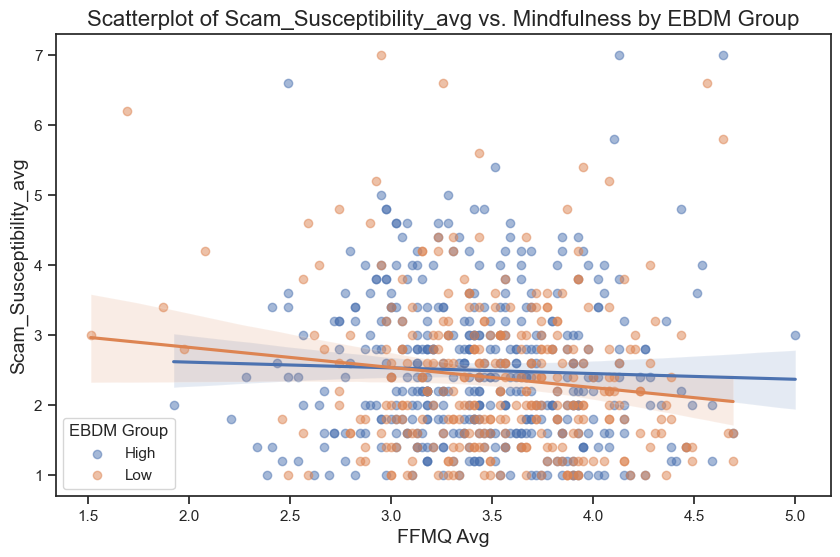

In [27]:
print("Model: Scam Susceptibility ~ FFMQ * EBDM\n")

import statsmodels.api as sm
import pandas as pd

# Assuming 'combined_df' already exists and has the relevant data.
# Ensure 'FF_avg' and 'Age' are numeric
fl['FF_avg'] = pd.to_numeric(fl['FF_avg'], errors='coerce')
fl['EBDM_avg'] = pd.to_numeric(fl['EBDM_avg'], errors='coerce')
fl['Scam_Susceptibility_avg'] = pd.to_numeric(fl['Scam_Susceptibility_avg'], errors='coerce')

# Drop any rows with missing values in the required columns
fl = fl.dropna(subset=['FF_avg', 'EBDM_avg', 'Scam_Susceptibility_avg'])

# Create the interaction term between Age and FF_avg
fl['EBDM_FF_Interaction'] = fl['EBDM_avg'] * fl['FF_avg']

# Prepare the independent variables (FF_avg, Age, and the interaction term)
X = fl[['FF_avg', 'EBDM_avg', 'EBDM_FF_Interaction']]

# Add a constant for the intercept
X = sm.add_constant(X)

# Dependent variable
y = fl['Scam_Susceptibility_avg']

# Fit the Poisson regression model
poisson_model = sm.GLM(y, X, family=sm.families.Poisson()).fit()

# Output the regression results
print(poisson_model.summary())

# Create scatterplot with different colors for age groups with trend lines and confidence intervals
fl['EBDM_Group'] = np.where(fl['EBDM_avg'] >= fl['EBDM_avg'].median(), 'High', 'Low')
plt.figure(figsize=(10, 6))
for ebdm_group in fl['EBDM_Group'].unique():
    subset = fl[fl['EBDM_Group'] == ebdm_group]
    sns.regplot(x='FF_avg', y='Scam_Susceptibility_avg', data=subset, 
                label=ebdm_group, 
                scatter_kws={'alpha': 0.5}, 
                line_kws={},  # No label for trend line
                ci=95)  # 95% confidence interval

plt.title('Scatterplot of Scam_Susceptibility_avg vs. Mindfulness by EBDM Group', fontsize=16)
plt.xlabel('FFMQ Avg', fontsize=14)
plt.ylabel('Scam_Susceptibility_avg', fontsize=14)
plt.legend(title='EBDM Group')
plt.grid(False)
plt.show()

Model: CB ~ FFMQ * EBDM

                   Generalized Linear Model Regression Results                   
Dep. Variable:     Confirmation_bias_avg   No. Observations:                  732
Model:                               GLM   Df Residuals:                      728
Model Family:                    Poisson   Df Model:                            3
Link Function:                       Log   Scale:                          1.0000
Method:                             IRLS   Log-Likelihood:                -1134.3
Date:                   Mon, 27 Jan 2025   Deviance:                       42.253
Time:                           19:33:40   Pearson chi2:                     42.2
No. Iterations:                        4   Pseudo R-squ. (CS):           0.001963
Covariance Type:               nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------

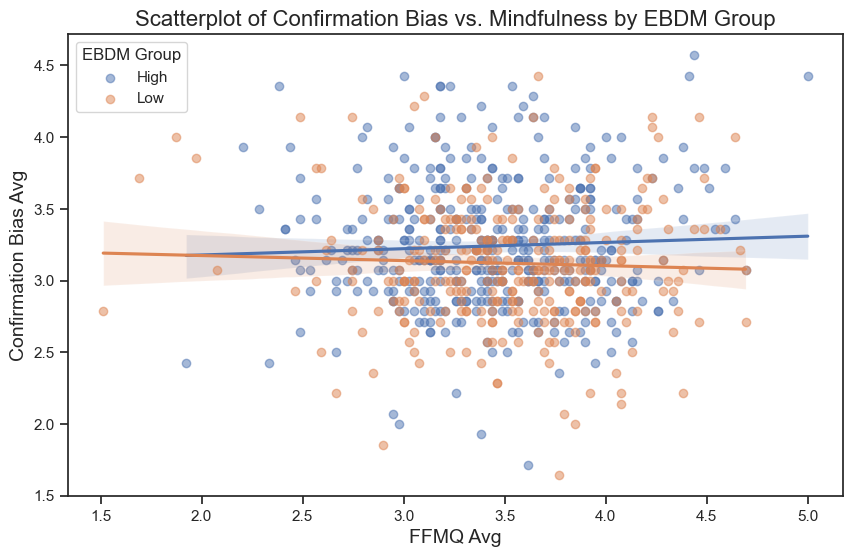

In [29]:
print("Model: CB ~ FFMQ * EBDM\n")

import statsmodels.api as sm
import pandas as pd

# Assuming 'combined_df' already exists and has the relevant data.
# Ensure 'FF_avg' and 'Age' are numeric
fl['FF_avg'] = pd.to_numeric(fl['FF_avg'], errors='coerce')
fl['EBDM_avg'] = pd.to_numeric(fl['EBDM_avg'], errors='coerce')
fl['Confirmation_bias_avg'] = pd.to_numeric(fl['Confirmation_bias_avg'], errors='coerce')

# Drop any rows with missing values in the required columns
fl = fl.dropna(subset=['FF_avg', 'EBDM_avg', 'Confirmation_bias_avg'])

# Create the interaction term between Age and FF_avg
fl['EBDM_FF_Interaction'] = fl['EBDM_avg'] * fl['FF_avg']

# Prepare the independent variables (FF_avg, Age, and the interaction term)
X = fl[['FF_avg', 'EBDM_avg', 'EBDM_FF_Interaction']]

# Add a constant for the intercept
X = sm.add_constant(X)

# Dependent variable
y = fl['Confirmation_bias_avg']

# Fit the Poisson regression model
poisson_model = sm.GLM(y, X, family=sm.families.Poisson()).fit()

# Output the regression results
print(poisson_model.summary())

# Create scatterplot with different colors for age groups with trend lines and confidence intervals
fl['EBDM_Group'] = np.where(fl['EBDM_avg'] >= fl['EBDM_avg'].median(), 'High', 'Low')
plt.figure(figsize=(10, 6))
for ebdm_group in fl['EBDM_Group'].unique():
    subset = fl[fl['EBDM_Group'] == ebdm_group]
    sns.regplot(x='FF_avg', y='Confirmation_bias_avg', data=subset, 
                label=ebdm_group, 
                scatter_kws={'alpha': 0.5}, 
                line_kws={},  # No label for trend line
                ci=95)  # 95% confidence interval

plt.title('Scatterplot of Confirmation Bias vs. Mindfulness by EBDM Group', fontsize=16)
plt.xlabel('FFMQ Avg', fontsize=14)
plt.ylabel('Confirmation Bias Avg', fontsize=14)
plt.legend(title='EBDM Group')
plt.grid(False)
plt.show()